# DEMAND FORECASTING & INVENTORY DECISION PROTOTYPE
FULLY COMMENTED FOR INTERVIEW / LEARNING PURPOSES

0. IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Fix random seed to ensure reproducibility. This makes synthetic data and model outputs deterministic.
np.random.seed(42)  

1. SYNTHETIC DATA GENERATION

In [2]:
n_skus = 25           # Number of distinct products (SKUs)
n_days = 730          # 24 months (~2 years of daily data)
dates = pd.date_range(start="2022-01-01", periods=n_days)  # Generate date range

data = []  # Will store each row of synthetic data

# Loop through each SKU to create demand series
for sku in range(n_skus):
    base_demand = np.random.randint(20, 100)  # Base demand level per SKU
    trend = np.linspace(0, np.random.randint(5, 20), n_days)  # Linear trend over time
    seasonality = 10 * np.sin(2 * np.pi * np.arange(n_days) / 7)  # Weekly seasonality pattern
    noise = np.random.normal(0, 5, n_days)  # Random noise for realism

    # External signals (sparse events impacting demand)
    promotion = np.random.binomial(1, 0.1, n_days)  # 10% chance of promotion on any day
    disruption = np.random.binomial(1, 0.05, n_days)  # 5% chance of supply disruption
    event = np.random.binomial(1, 0.05, n_days)  # 5% chance of external event

    # Combine all effects to create final demand
    demand = (
        base_demand         # base level
        + trend             # trend effect
        + seasonality       # weekly seasonality
        + noise             # random noise
        + promotion * 20    # promotion increases demand
        - disruption * 25   # disruption decreases demand
        + event * 15        # events boost demand
    )
    demand = np.maximum(demand, 0)  # Ensure demand cannot be negative

    # Append all daily data for this SKU
    for i in range(n_days):
        data.append([dates[i], sku, demand[i], promotion[i], disruption[i], event[i]])

# Convert to DataFrame for further processing
df = pd.DataFrame(data, columns=[
    "date", "sku", "demand", "promotion", "disruption", "event"
])

2. FEATURE ENGINEERING

In [3]:
# Sort data by SKU and date to ensure proper lag/rolling calculation
df = df.sort_values(["sku", "date"])

# Lag features: capture short-term temporal dependencies
df["lag_1"] = df.groupby("sku")["demand"].shift(1)   # Previous day's demand
df["lag_7"] = df.groupby("sku")["demand"].shift(7)   # Demand 7 days ago (weekly seasonality)

# Rolling statistics: capture local trends & volatility
df["rolling_mean_7"] = df.groupby("sku")["demand"].shift(1).rolling(7).mean()  # mean of past week
df["rolling_std_7"] = df.groupby("sku")["demand"].shift(1).rolling(7).std()    # std deviation of past week

# Drop rows with NaN (first few rows per SKU lack sufficient history for lags/rolling)
df = df.dropna()  

3. TRAIN / TEST SPLIT

In [4]:
# Split data chronologically: first 80% of dates for training, last 20% for testing
split_date = df["date"].quantile(0.8)
train = df[df["date"] <= split_date]
test = df[df["date"] > split_date]

4. MODEL TRAINING

In [5]:
# Define feature sets
features_base = ["lag_1", "lag_7", "rolling_mean_7", "rolling_std_7"]  # baseline features
features_full = features_base + ["promotion", "disruption", "event"]   # full model including external signals

# Prepare training and testing inputs
X_train_base = train[features_base]
X_test_base = test[features_base]
X_train_full = train[features_full]
X_test_full = test[features_full]

y_train = train["demand"]
y_test = test["demand"]

# Initialize regression models
model_base = LinearRegression()
model_full = LinearRegression()

# Fit models to training data
model_base.fit(X_train_base, y_train)
model_full.fit(X_train_full, y_train)

# Predict on test set
test["pred_base"] = model_base.predict(X_test_base)
test["pred_full"] = model_full.predict(X_test_full)

/var/folders/zv/hgmkmp6x6yvbdrxtsn9vj5800000gn/T/ipykernel_99050/2926236833.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["pred_base"] = model_base.predict(X_test_base)
/var/folders/zv/hgmkmp6x6yvbdrxtsn9vj5800000gn/T/ipykernel_99050/2926236833.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["pred_full"] = model_full.predict(X_test_full)


5. MODEL PERFORMANCE

In [6]:
# Define evaluation function to compute MAE and RMSE
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

# Evaluate baseline and full models
mae_base, rmse_base = evaluate(y_test, test["pred_base"])
mae_full, rmse_full = evaluate(y_test, test["pred_full"])

# Print results
print("\n" + "="*50)
print("MODEL PERFORMANCE")
print("="*50)
print(f"Baseline  -> MAE: {mae_base:.2f}, RMSE: {rmse_base:.2f}")
print(f"Full Model-> MAE: {mae_full:.2f}, RMSE: {rmse_full:.2f}")
print(f"MAE ↓ {(mae_base - mae_full)/mae_base*100:.2f}%")
print(f"RMSE ↓ {(rmse_base - rmse_full)/rmse_base*100:.2f}%")


MODEL PERFORMANCE
Baseline  -> MAE: 8.95, RMSE: 11.85
Full Model-> MAE: 6.53, RMSE: 8.26
MAE ↓ 27.02%
RMSE ↓ 30.36%


6. VARIANCE REDUCTION

In [7]:
# Compute absolute errors
test["error_base"] = abs(test["demand"] - test["pred_base"])
test["error_full"] = abs(test["demand"] - test["pred_full"])

# Compute variance reduction
var_base = test["error_base"].var()
var_full = test["error_full"].var()

print("\n" + "="*50)
print("VARIANCE REDUCTION")
print("="*50)
print(f"Baseline Variance: {var_base:.2f}")
print(f"Full Model Var:    {var_full:.2f}")
print(f"Reduction: {(var_base - var_full)/var_base*100:.2f}%")


VARIANCE REDUCTION
Baseline Variance: 60.38
Full Model Var:    25.47
Reduction: 57.82%


/var/folders/zv/hgmkmp6x6yvbdrxtsn9vj5800000gn/T/ipykernel_99050/4262616401.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["error_base"] = abs(test["demand"] - test["pred_base"])
/var/folders/zv/hgmkmp6x6yvbdrxtsn9vj5800000gn/T/ipykernel_99050/4262616401.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["error_full"] = abs(test["demand"] - test["pred_full"])


7. FEATURE IMPORTANCE

In [8]:
# Coefficients of the linear regression
coef_df = pd.DataFrame({
    "feature": features_full,
    "coef": model_full.coef_
}).sort_values(by="coef", key=abs, ascending=False)

print("\n" + "="*50)
print("FEATURE IMPACT")
print("="*50)
print(coef_df)


FEATURE IMPACT
          feature       coef
5      disruption -24.884466
4       promotion  20.040327
6           event  15.304674
2  rolling_mean_7   0.431671
1           lag_7   0.346056
0           lag_1   0.183932
3   rolling_std_7  -0.024118


8. HIGH-UNCERTAINTY SKUs

In [9]:
# Compute average prediction error per SKU
test["error"] = abs(test["demand"] - test["pred_full"])
sku_error = test.groupby("sku")["error"].mean().sort_values(ascending=False)

print("\n" + "="*50)
print("HIGH-UNCERTAINTY SKUs")
print("="*50)
print(sku_error.head())


HIGH-UNCERTAINTY SKUs
sku
19    7.421823
5     7.052287
15    7.007279
3     6.919970
0     6.917371
Name: error, dtype: float64


/var/folders/zv/hgmkmp6x6yvbdrxtsn9vj5800000gn/T/ipykernel_99050/1201995115.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["error"] = abs(test["demand"] - test["pred_full"])


9. SCENARIO SIMULATION

In [10]:
def simulate_scenarios(df_sample, model):
    """
    Simulates multiple demand scenarios by adjusting lag features and external signals.
    """
    scenarios = []
    for multiplier in [0.8, 1.0, 1.2]:  # low, base, high demand
        for promo in [0, 1]:
            for disrupt in [0, 1]:
                temp = df_sample.copy()
                temp["lag_1"] *= multiplier
                temp["lag_7"] *= multiplier
                temp["promotion"] = promo
                temp["disruption"] = disrupt
                preds = model.predict(temp[features_full])
                scenarios.append({
                    "multiplier": multiplier,
                    "promotion": promo,
                    "disruption": disrupt,
                    "avg_demand": preds.mean()
                })
    return pd.DataFrame(scenarios)

# Sample 200 rows from test for simulation
scenario_results = simulate_scenarios(test.sample(200), model_full)

print("\n" + "="*50)
print("SCENARIO RESULTS")
print("="*50)
print(scenario_results)


SCENARIO RESULTS
    multiplier  promotion  disruption  avg_demand
0          0.8          0           0   72.100255
1          0.8          0           1   47.215789
2          0.8          1           0   92.140582
3          0.8          1           1   67.256115
4          1.0          0           0   80.723072
5          1.0          0           1   55.838606
6          1.0          1           0  100.763399
7          1.0          1           1   75.878933
8          1.2          0           0   89.345890
9          1.2          0           1   64.461423
10         1.2          1           0  109.386216
11         1.2          1           1   84.501750


10. SAFETY STOCK

In [11]:
def calculate_safety_stock(df, L=7, Z=1.65):
    """
    Calculates safety stock per SKU.
    L = lead time (days)
    Z = service level factor (1.65 ≈ 95% service level)
    """
    std = df.groupby("sku")["demand"].std()  # demand variability per SKU
    return Z * std * np.sqrt(L)

safety_stock = calculate_safety_stock(train)

print("\n" + "="*50)
print("SAFETY STOCK")
print("="*50)
print(safety_stock.sort_values(ascending=False).head())


SAFETY STOCK
sku
13    59.913567
5     58.409362
22    57.697739
6     57.407895
7     57.290533
Name: demand, dtype: float64


11. FINAL OUTPUT VISUALIZATIONS

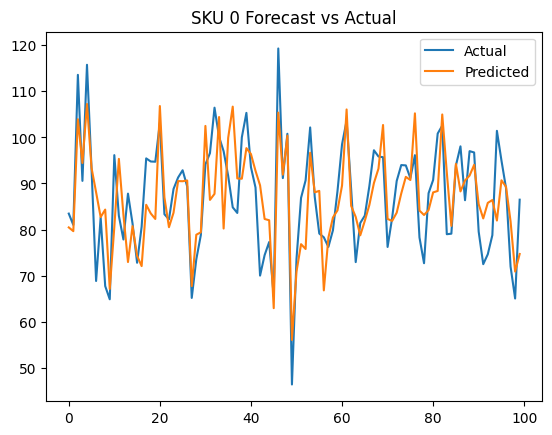

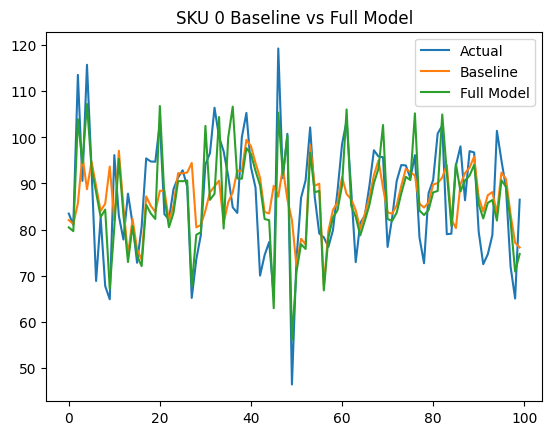

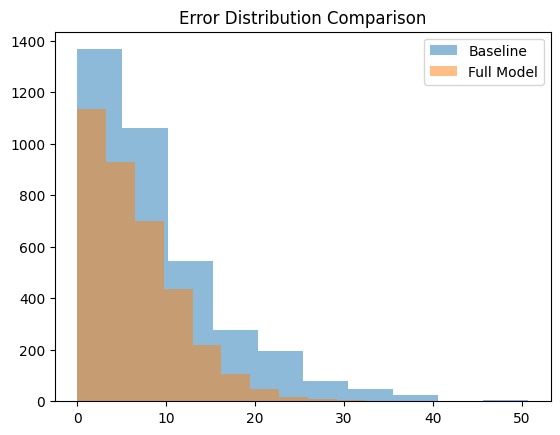

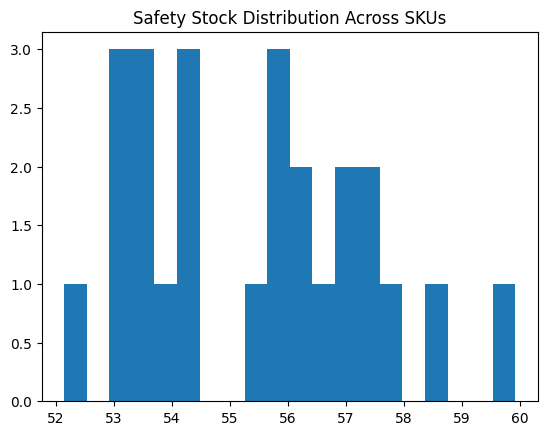

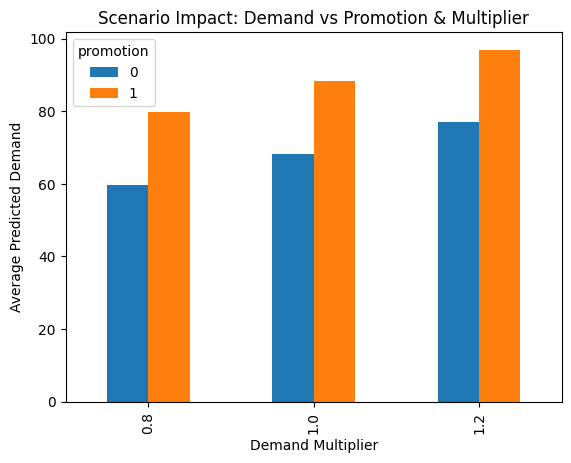

In [12]:
# --- 11.1 Forecast vs Actual (single SKU)
sample_sku = test["sku"].iloc[0]
sample_data = test[test["sku"] == sample_sku].head(100)

plt.figure()
plt.plot(sample_data["demand"].values, label="Actual")
plt.plot(sample_data["pred_full"].values, label="Predicted")
plt.legend()
plt.title(f"SKU {sample_sku} Forecast vs Actual")
plt.show()

# --- 11.2 Baseline vs Full Model
plt.figure()
plt.plot(sample_data["demand"].values, label="Actual")
plt.plot(sample_data["pred_base"].values, label="Baseline")
plt.plot(sample_data["pred_full"].values, label="Full Model")
plt.legend()
plt.title(f"SKU {sample_sku} Baseline vs Full Model")
plt.show()

# --- 11.3 Error Distribution
plt.figure()
plt.hist(test["error_base"], alpha=0.5, label="Baseline")
plt.hist(test["error_full"], alpha=0.5, label="Full Model")
plt.legend()
plt.title("Error Distribution Comparison")
plt.show()

# --- 11.4 Safety Stock Distribution
plt.figure()
plt.hist(safety_stock, bins=20)
plt.title("Safety Stock Distribution Across SKUs")
plt.show()

# --- 11.5 Scenario Impact Visualization
pivot = scenario_results.pivot_table(
    values="avg_demand",
    index="multiplier",
    columns="promotion"
)
pivot.plot(kind="bar")
plt.title("Scenario Impact: Demand vs Promotion & Multiplier")
plt.xlabel("Demand Multiplier")
plt.ylabel("Average Predicted Demand")
plt.show()